In [1]:
# Let us implement tranferlearning techinque to classify plant images

In [1]:
# Let us import libraries

import os
import json
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications.resnet50 import preprocess_input

from tensorflow.keras.applications.resnet50 import ResNet50

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense,Dropout,GlobalAveragePooling2D

from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint,ReduceLROnPlateau

In [2]:
# Let us define dataset path
Train_Dir="./Tomato_Split/train"
Validation_Dir="./Tomato_Split/validation"
Test_Dir="./Tomato_Split/test"


In [3]:
#Step 3: Set Image Prameters

IMG_HEIGHT=224
IMG_WIDTH=224
BATCH_SIZE=32
EPOCHS=1

In [4]:
#Step 4 : Image Preporcessing and Augmentation
train_datagen=ImageDataGenerator(
    
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
    
)

validation_datagen=ImageDataGenerator(
    preprocessing_function=preprocess_input
)





In [5]:
# Load dataset

# Step 5 : Load Images from folder

train_data=train_datagen.flow_from_directory(
    
    Train_Dir,
    target_size=(IMG_HEIGHT,IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)


validation_data=validation_datagen.flow_from_directory(
    
    Validation_Dir,
    target_size=(IMG_HEIGHT,IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data=validation_datagen.flow_from_directory(
    
    Test_Dir,
    target_size=(IMG_HEIGHT,IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES=train_data.num_classes
print("Number of classes : ",NUM_CLASSES)
print("Class Labels : ",train_data.class_indices)

# Let us save class names

with open("class_names.json","w") as f:
    json.dump(train_data.class_indices,f)
    
"""
f=open("demo.txt",w)
f.write("hello")
f.close()

with open("demo.txt","w") as f:
    f.write("hello")

"""


Found 3100 images belonging to 10 classes.
Found 660 images belonging to 10 classes.
Found 680 images belonging to 10 classes.
Number of classes :  10
Class Labels :  {'bacterial_spot': 0, 'early_blight': 1, 'healthy': 2, 'late_blight': 3, 'leaf_mold': 4, 'mosaic_virus': 5, 'septoria_leaf_spot': 6, 'target_spot': 7, 'twospotted_spider_mite': 8, 'yellow_leaf_curl_virus': 9}


'\nf=open("demo.txt",w)\nf.write("hello")\nf.close()\n\nwith open("demo.txt","w") as f:\n    f.write("hello")\n\n'

In [6]:
# Load Resnet 50

base_model=ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_HEIGHT,IMG_WIDTH,3)
)

#Feeze all layers 

base_model.trainable=False

In [7]:
# Let us add customer layers

x=base_model.output
x=GlobalAveragePooling2D()(x)

x=Dense(512,activation='relu')(x)
x=Dropout(0.5)(x)

output=Dense(NUM_CLASSES,activation='softmax')(x)
model=Model(inputs=base_model.input,outputs=output)



In [8]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,641,930 (94.00 MB)

 Trainable params: 1,054,218 (4.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [9]:
# Compile model

model.compile(
    
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
# Let us set call backs

early_stop=EarlyStopping(
    
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [11]:
checkpoint=ModelCheckpoint(
    "best_resnet50.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [12]:
reduce_lr=ReduceLROnPlateau(
    
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [13]:
#Let us train the model

history=model.fit(
    
    train_data,
    validation_data=validation_data,
    epochs=EPOCHS,
    callbacks=[early_stop,checkpoint],
    verbose=1
)

97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.4485 - loss: 1.8698
Epoch 1: val_accuracy improved from None to 0.79697, saving model to best_resnet50.keras
97/97 ━━━━━━━━━━━━━━━━━━━━ 750s 8s/step - accuracy: 0.5910 - loss: 1.2608 - val_accuracy: 0.7970 - val_loss: 0.6038


In [14]:
# let us save model

model.save("tomato_resnet50.keras")

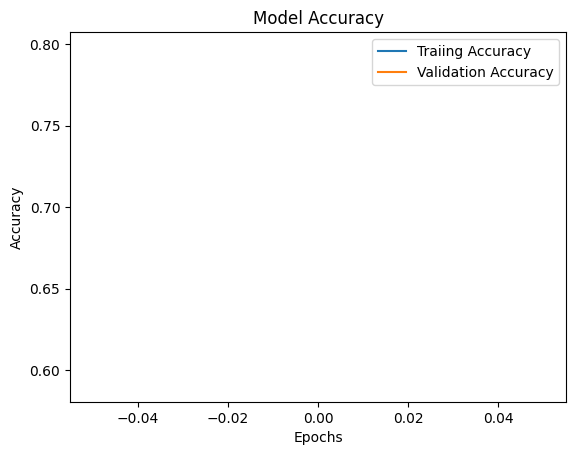

In [15]:
# Step 12 Plot accuracy and loss
import matplotlib.pyplot as plot
plot.figure()

plot.plot(history.history['accuracy'],label='Traiing Accuracy')

plot.plot(history.history['val_accuracy'],
          label='Validation Accuracy')
plot.title('Model Accuracy')
plot.xlabel('Epochs')
plot.ylabel('Accuracy')
plot.legend()
plot.show()



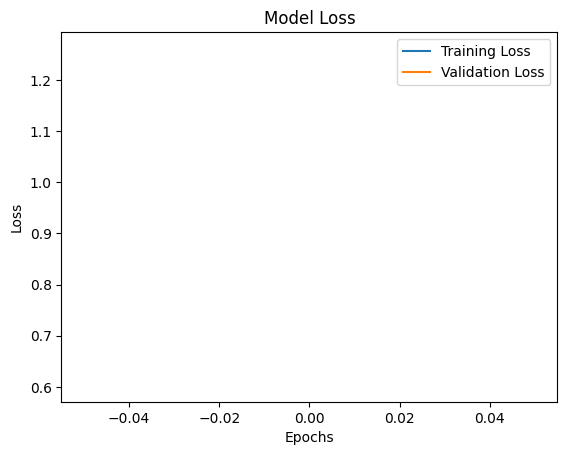

In [16]:
plot.figure()
plot.plot( history.history['loss'],label='Training Loss')
plot.plot( history.history['val_loss'],label='Validation Loss')

plot.title("Model Loss")
plot.xlabel('Epochs')
plot.ylabel('Loss')
plot.legend()
plot.show()


In [ ]:
import numpy as np

pred=model.predict(test_data)
pred_classes=np.argmax(pred,axis=1)

12/22 ━━━━━━━━━━━━━━━━━━━━ 1:00 6s/step

In [ ]:
true_classes=test_data.classes
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score


In [ ]:
cm=confusion_matrix(true_classes,pred_classes,)
print(cm)

cr=classification_report(true_classes,pred_classes)
print(cr)